# Step Analysis

Analysis of step data from NHANES accelerometer data.

**Note:** Only 2005-2006 data includes step counts (PAXSTEP). This notebook will not work with 2003-2004 data.

# Imports

In [1]:
import altair as alt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from utils import CHAR_LOOKUP, flatten_columns, get_datadir, get_processed_datadir

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 1000)
alt.data_transformers.enable("vegafusion")
alt.renderers.enable('png')

RendererRegistry.enable('png')

# Parameters

In [3]:
year: str = "2005-2006"

In [4]:
datadir = get_datadir(year)
processeddir = get_processed_datadir(year)
print(f"Raw data: {datadir}")
print(f"Processed data: {processeddir}")

Raw data: /Users/andyreagan/projects/2025/NHANES/data/raw/2005-2006
Processed data: /Users/andyreagan/projects/2025/NHANES/data/processed/2005-2006


# Load processed data

In [5]:
# Load the full data with bouts
paxraw = pd.read_parquet(
    processeddir / f"paxraw_{CHAR_LOOKUP[year].lower()}_met_worn_bouts.parquet"
)
print(f"Shape: {paxraw.shape}")

# Verify PAXSTEP exists
if "PAXSTEP" not in paxraw.columns:
    raise ValueError(f"PAXSTEP column not found in {year} data. This notebook only works with 2005-2006 data.")

Shape: (74874095, 20)


In [6]:
# Load person-level data
d_people = pd.read_parquet(
    processeddir / f"paxraw_{CHAR_LOOKUP[year].lower()}_people.parquet"
)
d_people.head()

,zero_steps_with_intensity_sum,too_many_steps_sum,max_intensity_sum,out_of_calibration_sum,out_of_calibration_last,unreliable_sum,unreliable_last,steps_filtered_500_sum,steps_filtered_300_sum,valid_day,PAXINTEN_sum
SEQN,,,,,,,,,,,
31128.0,0,0,0,0,0,0,0,8773.285714,10216.428571,6,345961.428571
31129.0,0,0,0,0,0,0,0,4555.142857,5213.428571,4,191478.428571
31131.0,0,0,0,0,0,0,0,6346.857143,7688.285714,6,250155.571429
31132.0,0,0,0,0,0,0,0,9984.857143,10688.571429,5,379224.000000
31133.0,0,0,0,0,0,0,0,3301.428571,3956.285714,5,172734.571429


In [7]:
# Load reliable people
d_reliable = pd.read_parquet(
    processeddir / f"paxraw_{CHAR_LOOKUP[year].lower()}_reliable_people.parquet"
)
d_reliable.shape

(6863, 11)

# Daily step aggregation

In [22]:
by_day = (
    paxraw.groupby(["SEQN", "PAXDAY"])
    .agg({"PAXSTEP": ["sum"], "PAXINTEN": ["sum", "mean", "max"]})
    .reset_index()
)
by_day.columns = flatten_columns(by_day.columns)
by_day.head()

,SEQN,PAXDAY,PAXSTEP_sum,PAXINTEN_sum,PAXINTEN_mean,PAXINTEN_max
0,31128.0,1.0,12668.0,377456.0,262.122222,4873.0
1,31128.0,2.0,11920.0,308309.0,214.103472,4166.0
2,31128.0,3.0,11169.0,324734.0,225.509722,3644.0
3,31128.0,4.0,6824.0,229846.0,159.615278,5190.0
4,31128.0,5.0,11342.0,304957.0,211.775694,7058.0


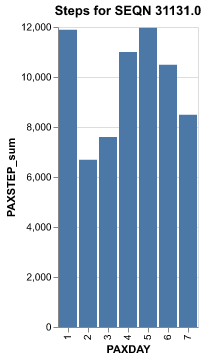

In [9]:
# Daily steps for one person
id = 2
alt.Chart(by_day.loc[by_day.SEQN == by_day.SEQN.unique()[id], :]).mark_bar().encode(
    x="PAXDAY:O", y="PAXSTEP_sum"
).properties(title=f"Steps for SEQN {by_day.SEQN.unique()[id]}")

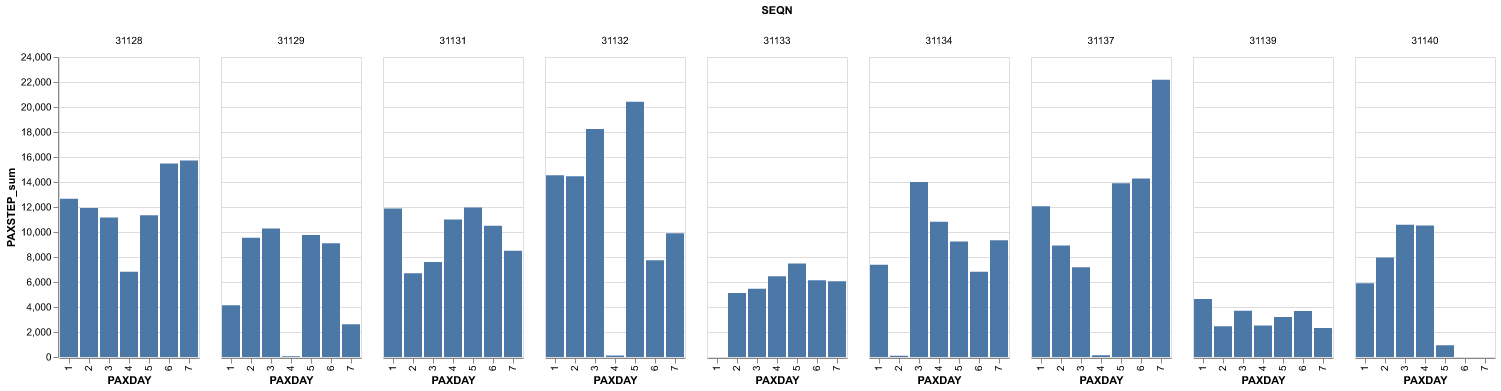

In [10]:
# Daily steps for multiple people
alt.Chart(by_day.loc[by_day.SEQN.isin(by_day.SEQN.unique()[:9]), :]).mark_bar().encode(
    x="PAXDAY:O", y="PAXSTEP_sum", column="SEQN:N"
)

# Individual activity/steps analysis

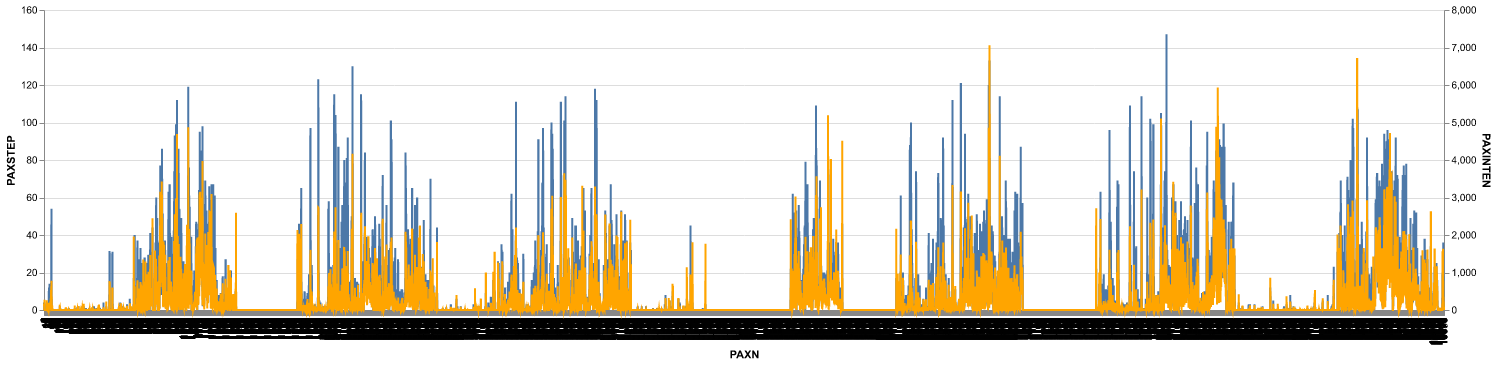

In [11]:
(
    alt.Chart(paxraw.loc[paxraw.SEQN == by_day.SEQN.unique()[0], :])
    .mark_line()
    .encode(x="PAXN:O", y="PAXSTEP")
    + alt.Chart(paxraw.loc[paxraw.SEQN == by_day.SEQN.unique()[0], :])
    .mark_line(color="orange")
    .encode(x="PAXN:O", y="PAXINTEN")
).properties(width=1400).resolve_scale(y="independent")

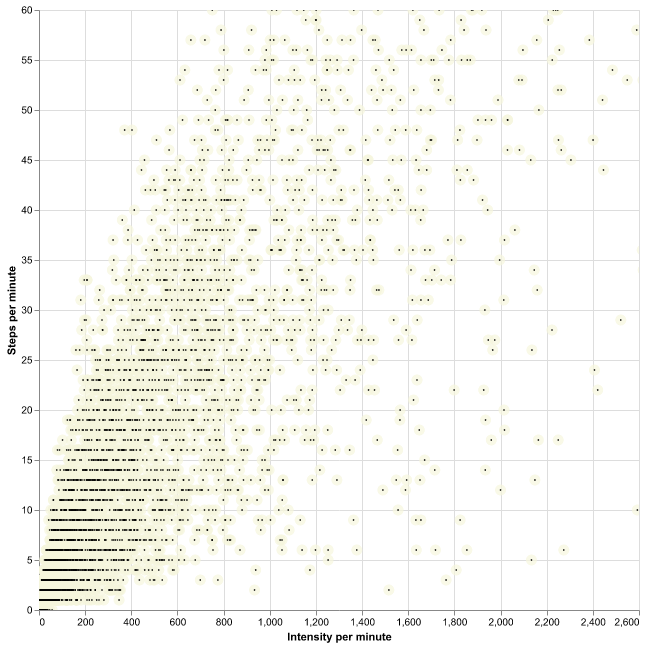

In [12]:
(
    alt.Chart(paxraw.loc[paxraw.SEQN == by_day.SEQN.unique()[0], :])
    .mark_circle(clip=True, opacity=0.7, color="#F5F5DC", size=120)
    .encode(
        alt.X(
            "PAXINTEN:Q",
            title="Intensity per minute",
            scale=alt.Scale(domain=[0, 2500]),
        ),
        alt.Y("PAXSTEP:Q", title="Steps per minute", scale=alt.Scale(domain=[0, 60])),
    )
    + alt.Chart(paxraw.loc[paxraw.SEQN == by_day.SEQN.unique()[0], :])
    .mark_circle(clip=True, opacity=1, color="black", size=3)
    .encode(x="PAXINTEN", y="PAXSTEP")
).properties(width=600, height=600)

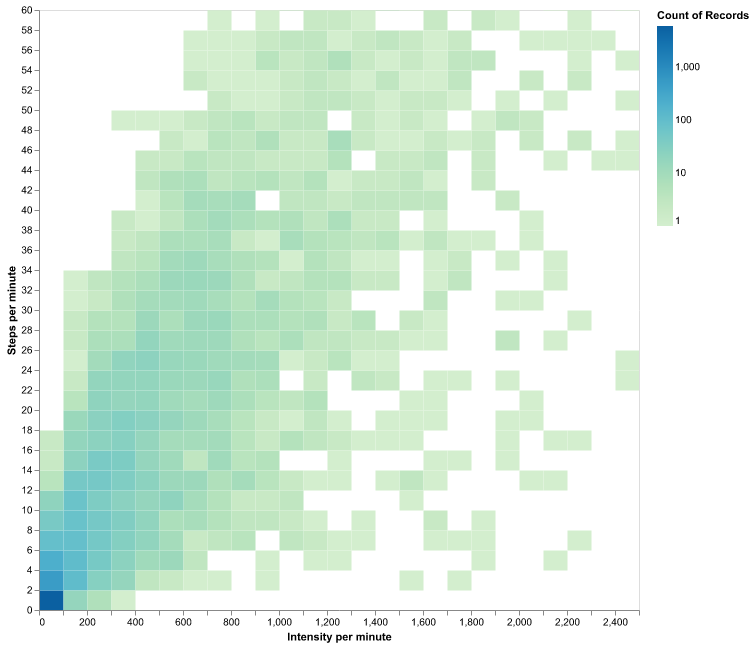

In [13]:
alt.Chart(paxraw.loc[paxraw.SEQN == by_day.SEQN.unique()[0], :]).mark_rect(clip=True).encode(
    alt.X(
        "PAXINTEN:Q",
        title="Intensity per minute",
        scale=alt.Scale(domain=[0, 2500]),
        bin=alt.Bin(maxbins=100),
    ),
    alt.Y(
        "PAXSTEP:Q",
        title="Steps per minute",
        scale=alt.Scale(domain=[0, 60]),
        bin=alt.Bin(maxbins=100),
    ),
    alt.Color("count():Q", scale=alt.Scale(scheme="greenblue", type="log")),
).properties(width=600, height=600)

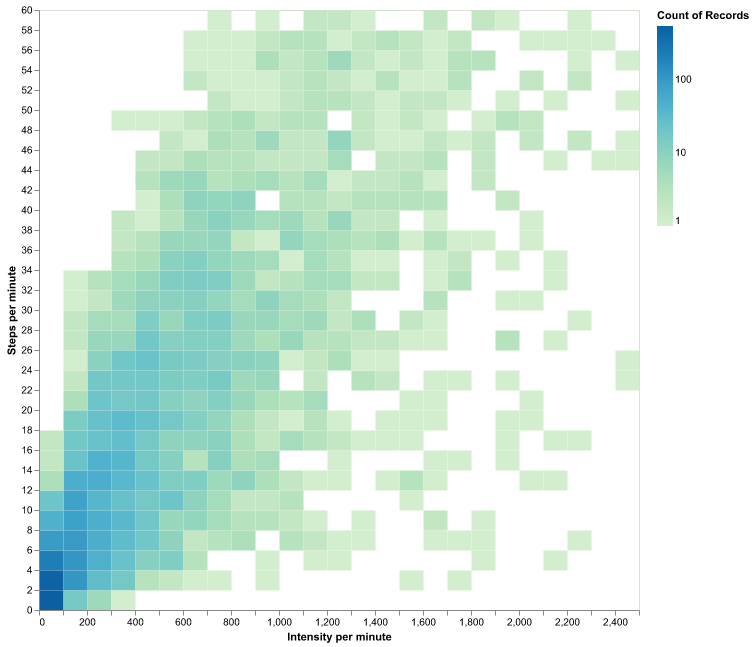

In [14]:
# Excluding zeros
alt.Chart(
    paxraw.loc[
        (paxraw.SEQN == by_day.SEQN.unique()[0]) & (paxraw.PAXINTEN > 0) & (paxraw.PAXSTEP > 0),
        :,
    ]
).mark_rect(clip=True).encode(
    alt.X(
        "PAXINTEN:Q",
        title="Intensity per minute",
        scale=alt.Scale(domain=[0, 2500]),
        bin=alt.Bin(maxbins=100),
    ),
    alt.Y(
        "PAXSTEP:Q",
        title="Steps per minute",
        scale=alt.Scale(domain=[0, 60]),
        bin=alt.Bin(maxbins=100),
    ),
    alt.Color("count():Q", scale=alt.Scale(scheme="greenblue", type="log")),
).properties(
    width=600, height=600
)

# Reliability filters (step-based)

In [15]:
d_unreliable = d_people.loc[
    (d_people.zero_steps_with_intensity_sum > 10)
    | (d_people.too_many_steps_sum > 10)
    | (d_people.max_intensity_sum > 10)
    | (d_people.out_of_calibration_last)
    | (d_people.unreliable_sum > 10)
    | (d_people.steps_filtered_500_sum > 200000),
    :,
]
d_unreliable.head(20)

,zero_steps_with_intensity_sum,too_many_steps_sum,max_intensity_sum,out_of_calibration_sum,out_of_calibration_last,unreliable_sum,unreliable_last,steps_filtered_500_sum,steps_filtered_300_sum,valid_day,PAXINTEN_sum
SEQN,,,,,,,,,,,
31154.0,0,0,0,10080,1,0,0,3773.142857,6016.000000,7,1.001300e+05
31163.0,3,0,0,10080,1,0,0,4451.142857,5287.285714,6,1.680881e+05
31180.0,91,709,0,0,0,9092,1,37285.571429,51537.714286,3,8.668543e+04
31181.0,3,0,0,10080,1,0,0,2693.857143,4333.000000,7,1.222759e+05
31192.0,30,345,0,0,0,10080,1,13657.000000,18503.714286,1,3.835557e+04
31193.0,0,0,0,10080,1,0,0,9644.142857,10371.857143,2,3.998269e+05
31203.0,0,0,0,10080,1,0,0,6299.428571,7980.142857,7,2.749851e+05
31211.0,0,0,0,10080,1,0,0,5260.571429,6351.000000,6,2.377843e+05
31230.0,0,0,0,10080,1,0,0,3711.857143,4409.428571,2,1.325093e+05


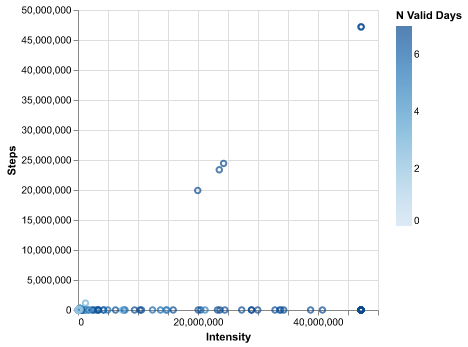

In [16]:
alt.Chart(d_unreliable).mark_point().encode(
    alt.X("PAXINTEN_sum", title="Intensity"),
    alt.Y("steps_filtered_500_sum", title="Steps"),
    alt.Color("valid_day", title="N Valid Days"),
)

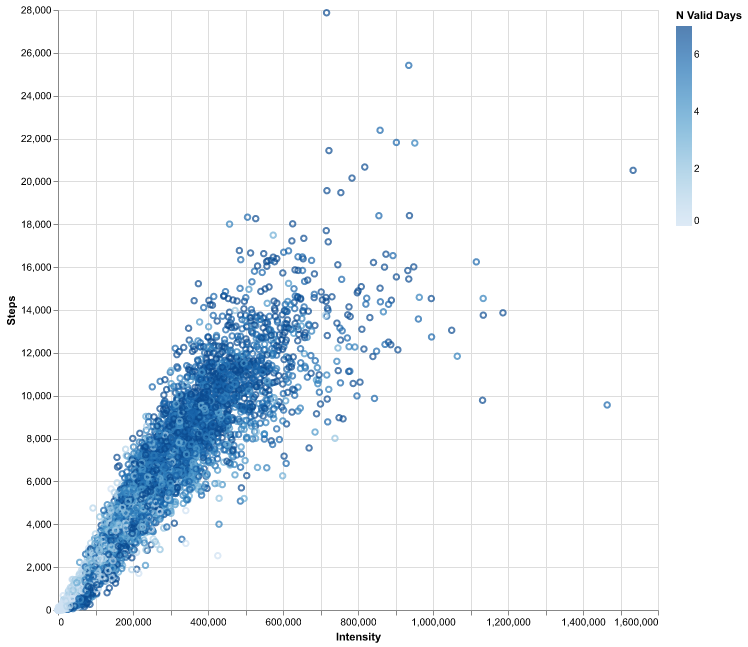

In [17]:
alt.Chart(d_reliable).mark_point().encode(
    alt.X("PAXINTEN_sum", title="Intensity"),
    alt.Y("steps_filtered_500_sum", title="Steps"),
    alt.Color("valid_day", title="N Valid Days"),
).properties(width=600, height=600)

# Correlation of steps and intensity

In [18]:
results = smf.ols("steps_filtered_500_sum ~ PAXINTEN_sum + 0", data=d_reliable).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                  
===========================================================================================
Dep. Variable:     steps_filtered_500_sum   R-squared (uncentered):                   0.952
Model:                                OLS   Adj. R-squared (uncentered):              0.952
Method:                     Least Squares   F-statistic:                          1.361e+05
Date:                    Thu, 18 Dec 2025   Prob (F-statistic):                        0.00
Time:                            12:34:06   Log-Likelihood:                         -59566.
No. Observations:                    6863   AIC:                                  1.191e+05
Df Residuals:                        6862   BIC:                                  1.191e+05
Df Model:                               1                                                  
Covariance Type:                nonrobust                                                  
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
PAXINTEN_sum     0.0219   5.95e-05    368.890      0.000       0.022       0.022
==============================================================================
Omnibus:                     3292.380   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           123330.142
Skew:                          -1.631   Prob(JB):                         0.00
Kurtosis:                      23.510   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

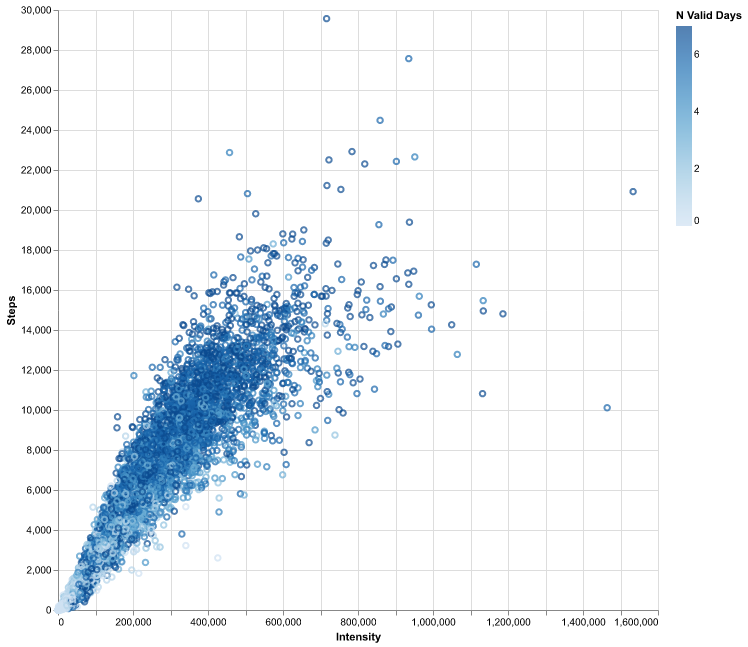

In [19]:
alt.Chart(d_reliable).mark_point().encode(
    alt.X("PAXINTEN_sum", title="Intensity"),
    alt.Y("steps_filtered_300_sum", title="Steps"),
    alt.Color("valid_day", title="N Valid Days"),
).properties(width=600, height=600)

In [20]:
results = smf.ols("steps_filtered_300_sum ~ PAXINTEN_sum + 0", data=d_reliable).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                  
===========================================================================================
Dep. Variable:     steps_filtered_300_sum   R-squared (uncentered):                   0.945
Model:                                OLS   Adj. R-squared (uncentered):              0.945
Method:                     Least Squares   F-statistic:                          1.178e+05
Date:                    Thu, 18 Dec 2025   Prob (F-statistic):                        0.00
Time:                            12:34:06   Log-Likelihood:                         -60936.
No. Observations:                    6863   AIC:                                  1.219e+05
Df Residuals:                        6862   BIC:                                  1.219e+05
Df Model:                               1                                                  
Covariance Type:                nonrobust                                                  
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
PAXINTEN_sum     0.0249   7.26e-05    343.254      0.000       0.025       0.025
==============================================================================
Omnibus:                     3685.092   Durbin-Watson:                   1.960
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           120091.436
Skew:                          -1.974   Prob(JB):                         0.00
Kurtosis:                      23.109   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

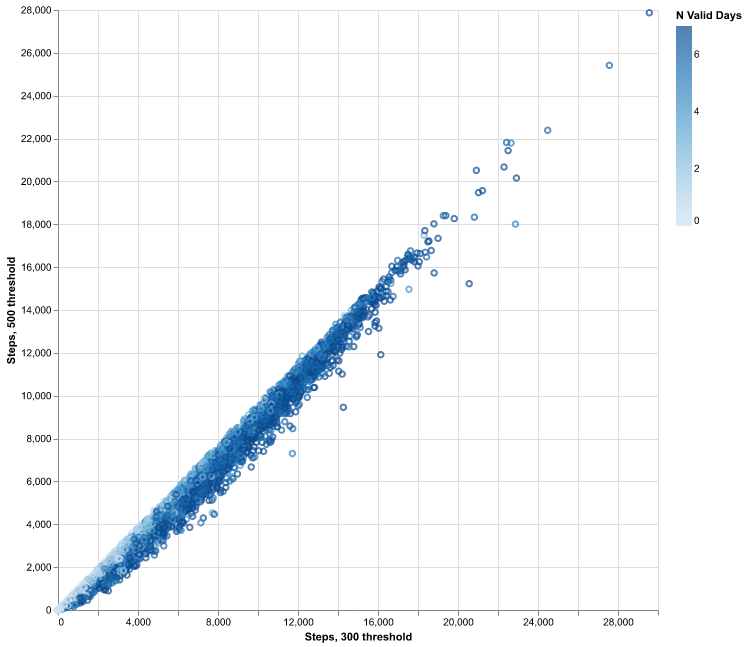

In [21]:
alt.Chart(d_reliable).mark_point().encode(
    alt.X("steps_filtered_300_sum", title="Steps, 300 threshold"),
    alt.Y("steps_filtered_500_sum", title="Steps, 500 threshold"),
    alt.Color("valid_day", title="N Valid Days"),
).properties(width=600, height=600)